In [7]:
# 1. Install necessary libraries
!pip install transformer_lens torch

import torch
from transformer_lens import HookedTransformer

# 2. Load a small, open-source model optimized for research
# 'gpt2-small' has 12 layers and 12 attention heads per layer.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# 3. Define our text prompts
clean_prompt = "John and Mary went to the store. John gave a drink to"
corrupted_prompt = "John and Mary went to the store. Mary gave a drink to"

# 4. Convert text into token IDs that the model understands
clean_tokens = model.to_tokens(clean_prompt)        # Shape: [1, 13]
corrupted_tokens = model.to_tokens(corrupted_prompt)  # Shape: [1, 13]

# 5. Identify the exact token IDs for the target names (" Mary" vs " John")
# We want to see how changing internal states flips the model's prediction.
mary_token_id = model.to_single_token(" Mary")
john_token_id = model.to_single_token(" John")

print(f"Tokenized sequence length: {clean_tokens.shape[1]} tokens.")


/tmp/ipykernel_1267/1915680846.py:10: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2-small", device=device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Tokenized sequence length: 14 tokens.


In [8]:
# 1. Run the corrupted prompt and save ALL internal activations to a cache
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

# 2. Define a "Hook Function"
# This function will intercept the model's internal processing mid-run.
def patch_residual_stream(target_activation, hook):
    """
    target_activation: The current tensor flowing through the model.
    hook: Contains metadata about which layer we are currently inside.
    """
    # Grab the exact matching layer's data from our corrupted run cache
    corrupted_activation = corrupted_cache[hook.name]

    # Target the last token position (-1), which corresponds to the word "to"
    # We replace the clean activation with the corrupted activation right here!
    target_activation[:, -1, :] = corrupted_activation[:, -1, :]
    return target_activation

# 3. Test patching at Layer 7 (the middle of the network)
# We use 'blocks.7.hook_resid_post' which means: "The residual stream right after Layer 7"
layer_to_patch = "blocks.7.hook_resid_post"

# 4. Run the clean tokens, but inject our hook function into Layer 7
patched_logits = model.run_with_hooks(
    clean_tokens,
    fwd_hooks=[(layer_to_patch, patch_residual_stream)]
)

# 5. Evaluate the results: Did the model flip its mind?
# Calculate log-probabilities for the next predicted token
patched_log_probs = torch.log_softmax(patched_logits[0, -1, :], dim=-1)

mary_prob = torch.exp(patched_log_probs[mary_token_id]).item() * 100
john_prob = torch.exp(patched_log_probs[john_token_id]).item() * 100

print(f"After patching Layer 7 at the 'to' token:")
print(f"Probability of predicting ' Mary': {mary_prob:.2f}%")
print(f"Probability of predicting ' John': {john_prob:.2f}%")


After patching Layer 7 at the 'to' token:
Probability of predicting ' Mary': 31.18%
Probability of predicting ' John': 28.56%


on 7th layer we can see a tiee between mary and john response but the system is still confused

In [9]:
# 1. Choose Floor 9 as our surgery target
layer_to_patch = "blocks.9.hook_resid_post"

# 2. Run the clean story, but pause and swap notes at Floor 9
patched_logits = model.run_with_hooks(
    clean_tokens,
    fwd_hooks=[(layer_to_patch, patch_residual_stream)]
)

# 3. Turn the factory's final guess into human-readable percentages
patched_log_probs = torch.log_softmax(patched_logits[0, -1, :], dim=-1)
mary_prob = torch.exp(patched_log_probs[mary_token_id]).item() * 100
john_prob = torch.exp(patched_log_probs[john_token_id]).item() * 100

# 4. Print the final results for Floor 9
print(f"--- Results after swapping thoughts at Floor 9 ---")
print(f"Probability of predicting ' Mary': {mary_prob:.2f}%")
print(f"Probability of predicting ' John': {john_prob:.2f}%")


--- Results after swapping thoughts at Floor 9 ---
Probability of predicting ' Mary': 1.89%
Probability of predicting ' John': 61.09%


9th layer is turning point as the percentage of response mary is nearly 0 and john is more han 60 percent


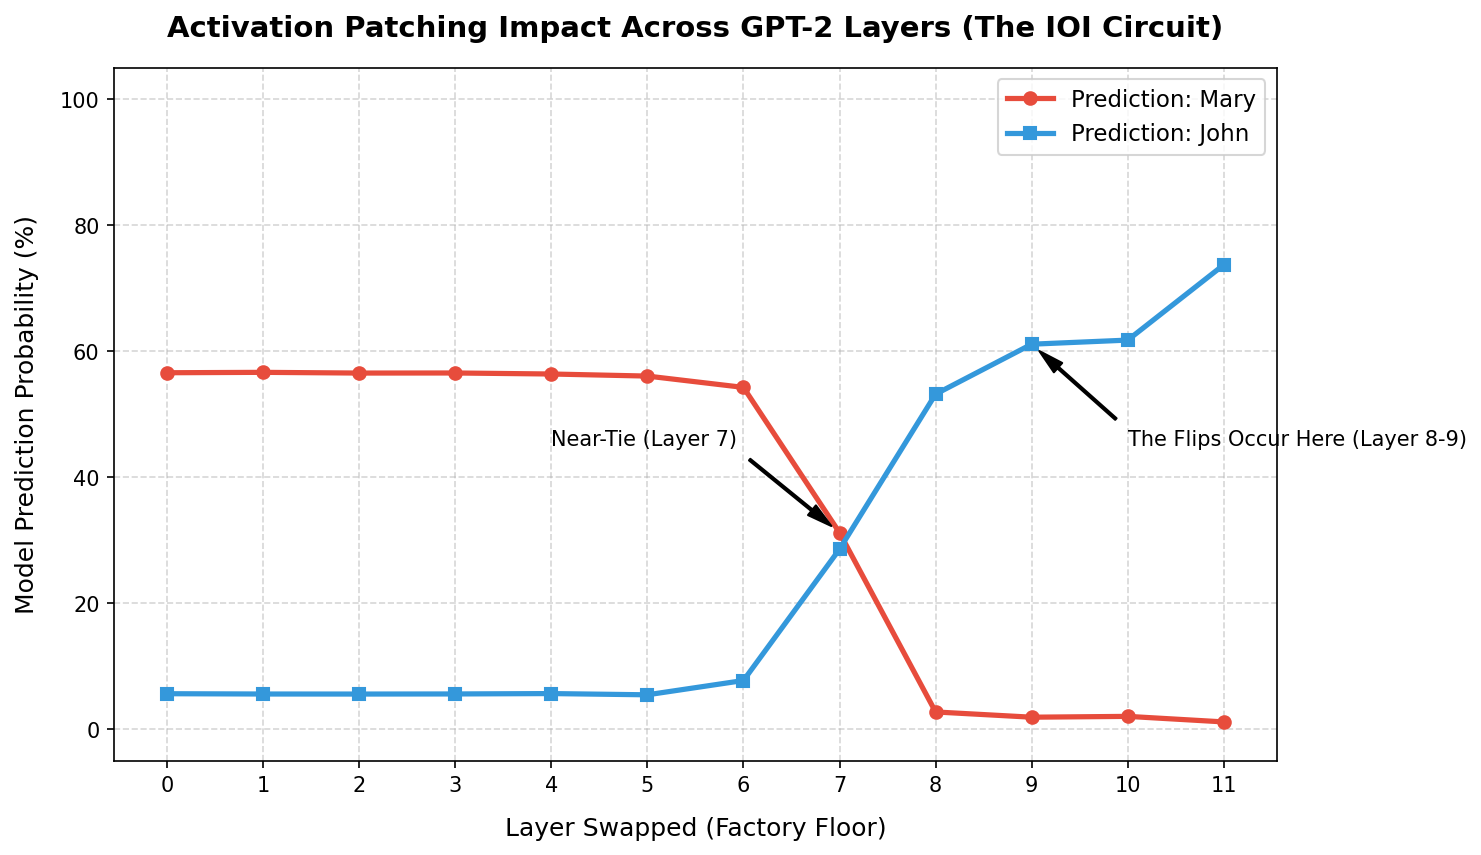

In [10]:
import matplotlib.pyplot as plt
import torch

# 1. Initialize lists to store our data for the graph
floors = list(range(12))
mary_percentages = []
john_percentages = []

# 2. Run the experiment for all 12 floors to gather data
for floor in floors:
    layer_to_patch = f"blocks.{floor}.hook_resid_post"

    patched_logits = model.run_with_hooks(
        clean_tokens,
        fwd_hooks=[(layer_to_patch, patch_residual_stream)]
    )

    patched_log_probs = torch.log_softmax(patched_logits[0, -1, :], dim=-1)
    mary_prob = torch.exp(patched_log_probs[mary_token_id]).item() * 100
    john_prob = torch.exp(patched_log_probs[john_token_id]).item() * 100

    # Save the numbers to our lists
    mary_percentages.append(mary_prob)
    john_percentages.append(john_prob)

# 3. Create the plot
plt.figure(figsize=(10, 6), dpi=150)

# Plot lines for Mary and John
plt.plot(floors, mary_percentages, marker='o', linewidth=2.5, color='#e74c3c', label='Prediction: Mary')
plt.plot(floors, john_percentages, marker='s', linewidth=2.5, color='#3498db', label='Prediction: John')

# 4. Style the graph to look academic and clean
plt.title("Activation Patching Impact Across GPT-2 Layers (The IOI Circuit)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Layer Swapped (Factory Floor)", fontsize=12, labelpad=10)
plt.ylabel("Model Prediction Probability (%)", fontsize=12, labelpad=10)
plt.xticks(floors) # Show every floor number on the X-axis
plt.ylim(-5, 105)  # Set percentage range from 0% to 100%
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# 5. Add text annotations to highlight your discoveries!
plt.annotate('Near-Tie (Layer 7)', xy=(7, 31.18), xytext=(4, 45),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))
plt.annotate('The Flips Occur Here (Layer 8-9)', xy=(9, 61.09), xytext=(10, 45),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

# 6. Save the graph as an image file on your computer
plt.savefig("ioi_activation_patching_results.png", bbox_inches='tight')
plt.show()
